In [1]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# Define transformations to apply to the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Example normalization
])

# Load the SVHN training dataset
train_dataset = datasets.SVHN(root='./data', split='train', transform=transform, download=True)

# Load the SVHN test dataset
test_dataset = datasets.SVHN(root='./data', split='test', transform=transform, download=True)

Using downloaded and verified file: ./data/train_32x32.mat
Using downloaded and verified file: ./data/test_32x32.mat


In [2]:
train_dataset.data.mean(axis=(0, 2, 3)), train_dataset.data.std(axis=(0, 2, 3))  # Check mean and std of training data

(array([111.60893668, 113.16127466, 120.56512767]),
 array([50.49768174, 51.2589843 , 50.24421614]))

In [3]:
import torch
from torch.utils.data import DataLoader

import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import matplotlib.pyplot as plt

def train_resnet18(optimizer_class, use_curvy=False, batch_size=128, plot=True, **optimizer_kwargs):
	# Set device
	device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
	
	# Create data loaders
	train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=16)
	test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=16)

	# Initialize ResNet-18 model
	model = models.resnet18(pretrained=False, num_classes=10)  # SVHN has 10 classes
	model = model.to(device)
	
	# Initialize optimizer
	if use_curvy:
		optimizer = optimizer_class(model.parameters(), model=model, **optimizer_kwargs)
	else:
		optimizer = optimizer_class(model.parameters(), **optimizer_kwargs)

	# Loss function
	criterion = nn.CrossEntropyLoss()
	
	# Training parameters
	num_epochs = 20
	train_losses = []
	test_losses = []
	
	for epoch in range(num_epochs):
		# Training phase
		model.train()
		train_loss = 0.0
		for batch_idx, (data, target) in enumerate(train_loader):
			data, target = data.to(device), target.to(device)
			
			optimizer.zero_grad()
			output = model(data)
			loss = criterion(output, target)
			loss.backward()
			optimizer.step()
			
			train_loss += loss.item()
		
		train_loss /= len(train_loader)
		train_losses.append(train_loss)
		
		# Testing phase
		model.eval()
		test_loss = 0.0
		total = 0
		total_correct = 0
		with torch.no_grad():
			for data, target in test_loader:
				data, target = data.to(device), target.to(device)
				output = model(data)
				loss = criterion(output, target)
				test_loss += loss.item()
				_, predicted = output.max(1)
				total += target.size(0)
				total_correct += predicted.eq(target).sum().item()
		
		test_loss /= len(test_loader)
		test_losses.append(test_loss)

		print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {total_correct/total:.4f}')
	
	if plot:
		# Plot loss curves
		plt.figure(figsize=(10, 6))
		plt.plot(range(1, num_epochs+1), train_losses, label='Training Loss')
		plt.plot(range(1, num_epochs+1), test_losses, label='Testing Loss')
		plt.xlabel('Epoch')
		plt.ylabel('Loss')
		plt.title('Training and Testing Loss Curves')
		plt.legend()
		plt.grid(True)
		plt.show()
	
	return model, train_losses, test_losses

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/autograd/__init__.py:266: UserWarning: Using backward() with create_graph=True will create a reference cycle between the parameter and its gradient which can cause a memory leak. We recommend using autograd.grad when creating the graph to avoid this. If you have to use this function, make sure to reset the .grad fields of your parameters to None after use to bre

Max curvature: 6.4719085693359375
Min curvature: 0.0
Max curvature: 6.956445693969727
Min curvature: 0.0
Max curvature: 2.7936975955963135
Min curvature: 0.0
Max curvature: 1.3076434135437012
Min curvature: 0.0
Max curvature: 1.006904125213623
Min curvature: 0.0
Max curvature: 0.8808834552764893
Min curvature: 0.0
Max curvature: 0.5962304472923279
Min curvature: 0.0
Max curvature: 0.6378911137580872
Min curvature: 0.0
Max curvature: 0.6046926379203796
Min curvature: 0.0
Max curvature: 0.48508599400520325
Min curvature: 0.0
Max curvature: 0.7295699119567871
Min curvature: 0.0
Epoch 1/20, Train Loss: 0.8562, Test Loss: 0.4831, Test Accuracy: 0.8524
Max curvature: 0.32523369789123535
Min curvature: 0.0
Max curvature: 0.3723262846469879
Min curvature: 0.0
Max curvature: 0.34888386726379395
Min curvature: 0.0
Max curvature: 0.21631883084774017
Min curvature: 0.0
Max curvature: 0.3709108829498291
Min curvature: 0.0
Max curvature: 0.3004639148712158
Min curvature: 0.0
Max curvature: 0.2507760

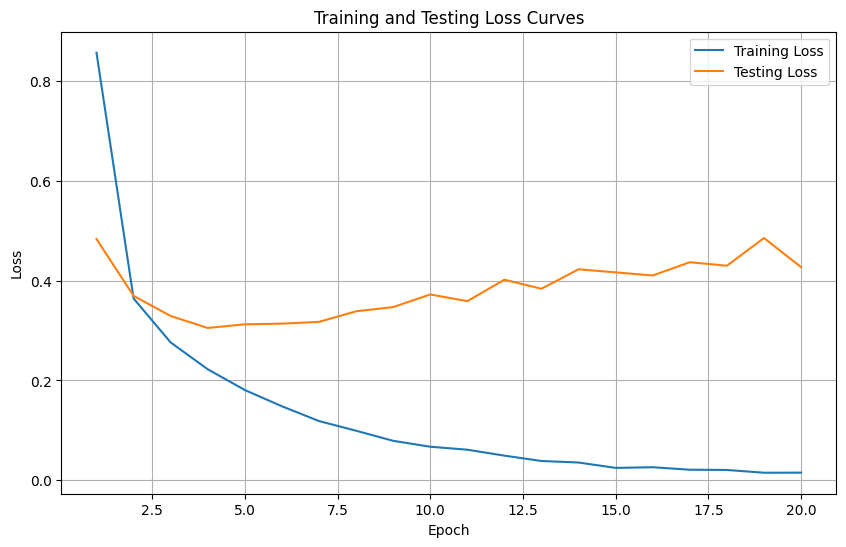

In [4]:
import torch
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy

# optimizer_curvy = Curvy(model_curvy.parameters())

train_x = torch.stack([x[0] for x in train_dataset])
train_y = torch.tensor([x[1] for x in train_dataset])

curvy_model, curvy_train, curvy_test = train_resnet18(Curvy, use_curvy=True, batch_size=64, lr=0.001, hessian_epsilon=1e-1, 
                        momentum=0.9, hessian_compute_interval=100, 
                        hessian_n_iter=100, criterion=nn.CrossEntropyLoss(), hessian_computer=hessian, 
                        train_x=train_x, train_y=train_y, cuda=True, n_hess_samples=1000)

/home/aarsh.wankar/miniconda/envs/ml/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/aarsh.wankar/miniconda/envs/ml/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch 1/20, Train Loss: 0.6753, Test Loss: 0.4282, Test Accuracy: 0.8675
Epoch 2/20, Train Loss: 0.3747, Test Loss: 0.3561, Test Accuracy: 0.8922
Epoch 3/20, Train Loss: 0.3072, Test Loss: 0.3017, Test Accuracy: 0.9113
Epoch 4/20, Train Loss: 0.2647, Test Loss: 0.2885, Test Accuracy: 0.9131
Epoch 5/20, Train Loss: 0.2293, Test Loss: 0.3028, Test Accuracy: 0.9096
Epoch 6/20, Train Loss: 0.1974, Test Loss: 0.2772, Test Accuracy: 0.9206
Epoch 7/20, Train Loss: 0.1719, Test Loss: 0.2358, Test Accuracy: 0.9347
Epoch 8/20, Train Loss: 0.1467, Test Loss: 0.2740, Test Accuracy: 0.9230
Epoch 9/20, Train Loss: 0.1241, Test Loss: 0.2956, Test Accuracy: 0.9219
Epoch 10/20, Train Loss: 0.1052, Test Loss: 0.2716, Test Accuracy: 0.9290
Epoch 11/20, Train Loss: 0.0861, Test Loss: 0.3113, Test Accuracy: 0.9230
Epoch 12/20, Train Loss: 0.0786, Test Loss: 0.3420, Test Accuracy: 0.9184
Epoch 13/20, Train Loss: 0.0659, Test Loss: 0.3371, Test Accuracy: 0.9230
Epoch 14/20, Train Loss: 0.0567, Test Loss: 0.3

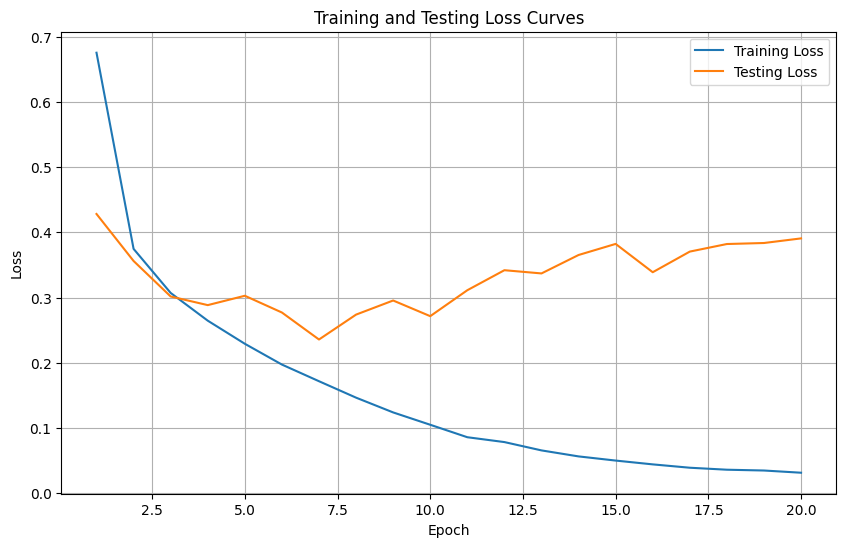

In [ ]:
# Train ResNet-18 with Adam optimizer
model, train_losses, test_losses = train_resnet18(optim.Adam, batch_size=64, lr=0.001)

In [ ]:
from PyHessian.pyhessian.hessian import hessian
from curvy import Curvy
import pandas as pd

# optimizer_curvy = Curvy(model_curvy.parameters())
# 3 ^ 4 = 81 combinations * 20 min = 1 days
batch_sizes = [64]
lrs = [1e-2, 1e-3, 1e-4]
hessian_epsilon = [1e-1, 1e-2, 1e-4]
momentums = [0.9, 0.5, 0]
hessian_compute_interval = [10, 50, 100]
hessian_n_iter = 100

results_df = pd.DataFrame(columns=['batch_size', 'lr', 'hessian_epsilon', 'momentum', 
						'hessian_compute_interval', 'hessian_n_iter', 'train_loss', 'test_loss'])

for batch_size in batch_sizes:
	for lr in lrs:
		for epsilon in hessian_epsilon:
			for momentum in momentums:
				for compute_interval in hessian_compute_interval:
					curvy_model, train_losses, test_losses = train_resnet18(Curvy, use_curvy=True, plot=False, batch_size=batch_size, lr=lr, hessian_epsilon=epsilon,
						momentum=momentum, hessian_compute_interval=compute_interval, 
						hessian_n_iter=hessian_n_iter, criterion=nn.CrossEntropyLoss(), 
						hessian_computer=hessian, train_x=train_dataset.data, 
						train_y=train_dataset.labels, cuda=True)

					train_loss = train_losses[-1]
					test_loss = test_losses[-1]
					results_df = results_df.append({
						'batch_size': batch_size,
						'lr': lr,
						'hessian_epsilon': epsilon,
						'momentum': momentum,
						'hessian_compute_interval': compute_interval,
						'hessian_n_iter': hessian_n_iter,
						'train_loss': train_loss,
						'test_loss': test_loss
					}, ignore_index=True)

results_df.to_csv('curvy_experiment_results.csv', index=False)
results_df.sort_values(by='train_loss', ascending=True, inplace=True)
results_df.head(10)  # Display top 10 results with lowest training loss